In [16]:
import pandas as pd
df = pd.read_csv('/content/hotel_booking2.csv')
print(df.head(5))
print(df.info())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  customer_type  \
0                        0                     0       2  ...      Transient   
1   

In [17]:

df = df.dropna(subset = ['is_canceled'])
num_col = df.select_dtypes(include = ['int64','float64']).columns.drop('is_canceled')
for col in num_col:
  df[col] = df[col].fillna(df[col].mean())
#drop the null values in the last column with null value
df = df.dropna(subset = ['country'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 118902 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118902 non-null  object 
 1   is_canceled                     118902 non-null  int64  
 2   lead_time                       118902 non-null  int64  
 3   arrival_date_year               118902 non-null  int64  
 4   arrival_date_month              118902 non-null  object 
 5   arrival_date_week_number        118902 non-null  int64  
 6   arrival_date_day_of_month       118902 non-null  int64  
 7   stays_in_weekend_nights         118902 non-null  int64  
 8   stays_in_week_nights            118902 non-null  int64  
 9   adults                          118902 non-null  int64  
 10  children                        118902 non-null  float64
 11  babies                          118902 non-null  int64  
 12  meal                 

In [18]:
#drop personal information that are clearly irrelevant to the prediction
df = df.drop(columns = ['name','email','phone-number','credit_card'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 118902 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118902 non-null  object 
 1   is_canceled                     118902 non-null  int64  
 2   lead_time                       118902 non-null  int64  
 3   arrival_date_year               118902 non-null  int64  
 4   arrival_date_month              118902 non-null  object 
 5   arrival_date_week_number        118902 non-null  int64  
 6   arrival_date_day_of_month       118902 non-null  int64  
 7   stays_in_weekend_nights         118902 non-null  int64  
 8   stays_in_week_nights            118902 non-null  int64  
 9   adults                          118902 non-null  int64  
 10  children                        118902 non-null  float64
 11  babies                          118902 non-null  int64  
 12  meal                 

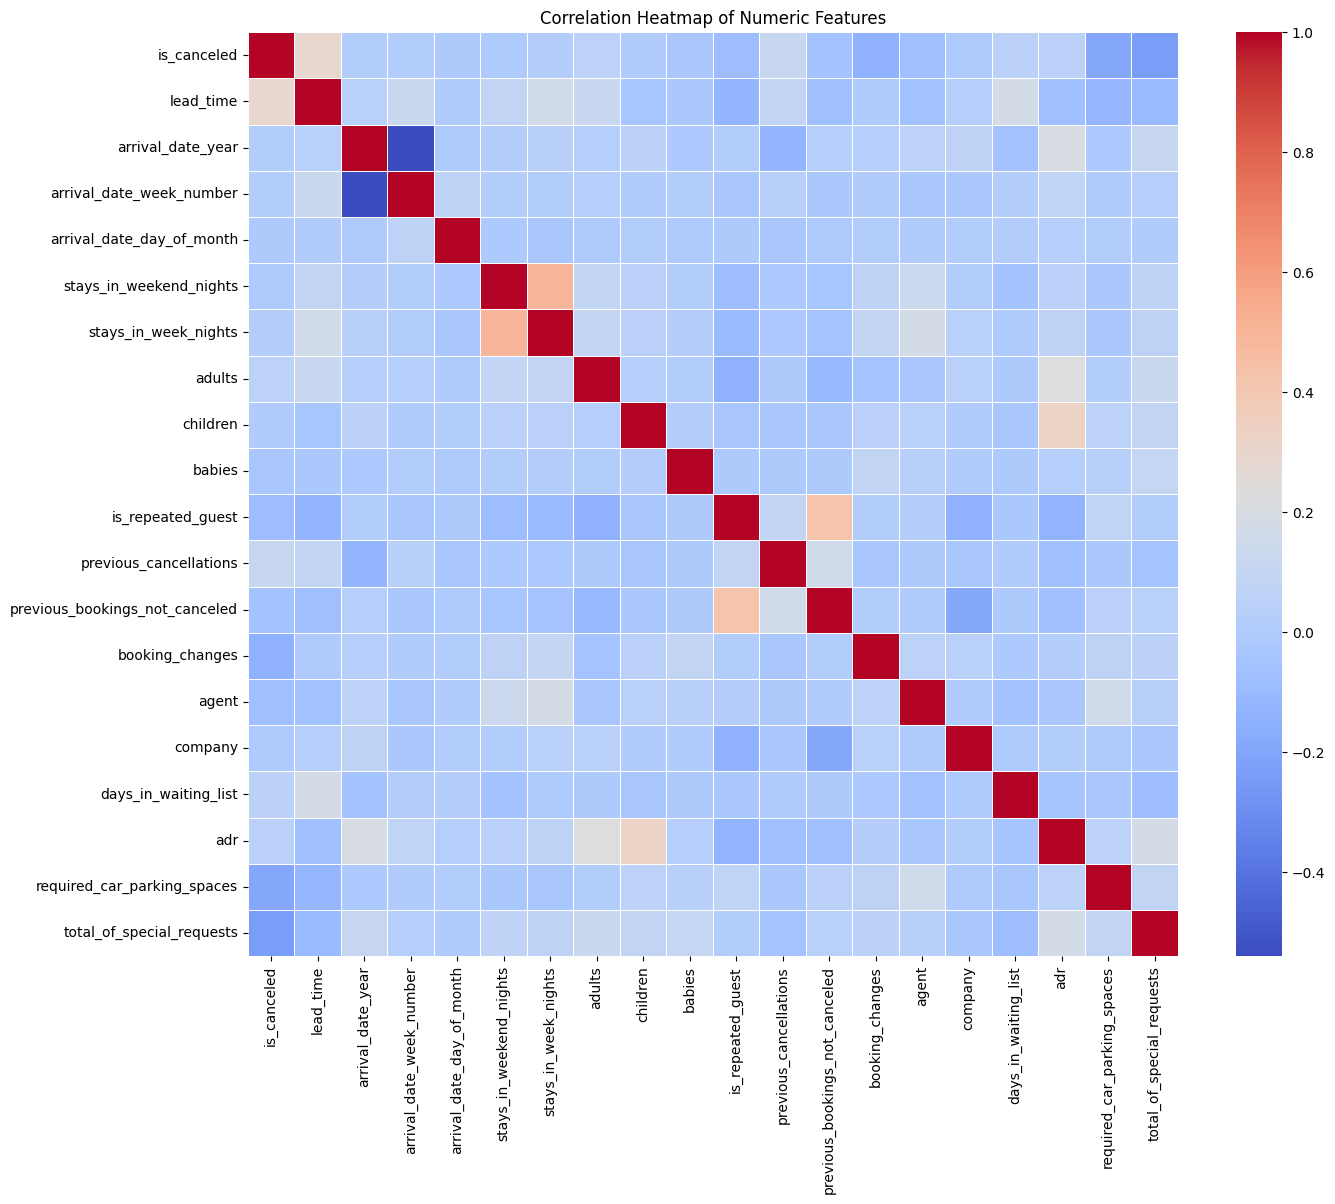

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(15, 12))

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=.5)

plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [20]:
#create training data
X = df.drop(columns = ['is_canceled'])
Y = df['is_canceled']

In [21]:
X1 = pd.get_dummies(X, drop_first=True)
display(X.head())

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,342,2015,July,27,1,0,0,2,0.0,...,No Deposit,86.693382,189.266735,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,737,2015,July,27,1,0,0,2,0.0,...,No Deposit,86.693382,189.266735,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,7,2015,July,27,1,0,1,1,0.0,...,No Deposit,86.693382,189.266735,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,13,2015,July,27,1,0,1,1,0.0,...,No Deposit,304.000000,189.266735,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,14,2015,July,27,1,0,2,2,0.0,...,No Deposit,240.000000,189.266735,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X1, Y, test_size=0.2,random_state = 42)
rf_classifier = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_classifier.fit(X_train, Y_train)
Y_pred = rf_classifier.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
classification_rep = classification_report(Y_test, Y_pred)
print(classification_rep)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14817
           1       1.00      1.00      1.00      8964

    accuracy                           1.00     23781
   macro avg       1.00      1.00      1.00     23781
weighted avg       1.00      1.00      1.00     23781



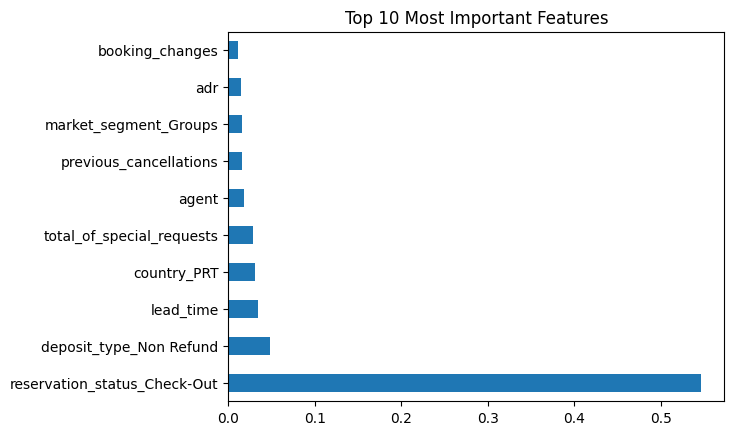

In [25]:
importances = pd.Series(rf_classifier.feature_importances_, index=X1.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Most Important Features")
plt.show()

In [26]:
#As it turns out in the feature importance diagram, there is feature leak present. The reservation_status provides too much data
X = df.drop(columns = ['is_canceled','reservation_status'])
Y = df['is_canceled']
X1 = pd.get_dummies(X, drop_first=True)


In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X1, Y, test_size=0.2,random_state = 42)
rf_classifier = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_classifier.fit(X_train, Y_train)
Y_pred = rf_classifier.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
classification_rep = classification_report(Y_test, Y_pred)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.90      0.97      0.93     14817
           1       0.94      0.82      0.87      8964

    accuracy                           0.91     23781
   macro avg       0.92      0.89      0.90     23781
weighted avg       0.91      0.91      0.91     23781



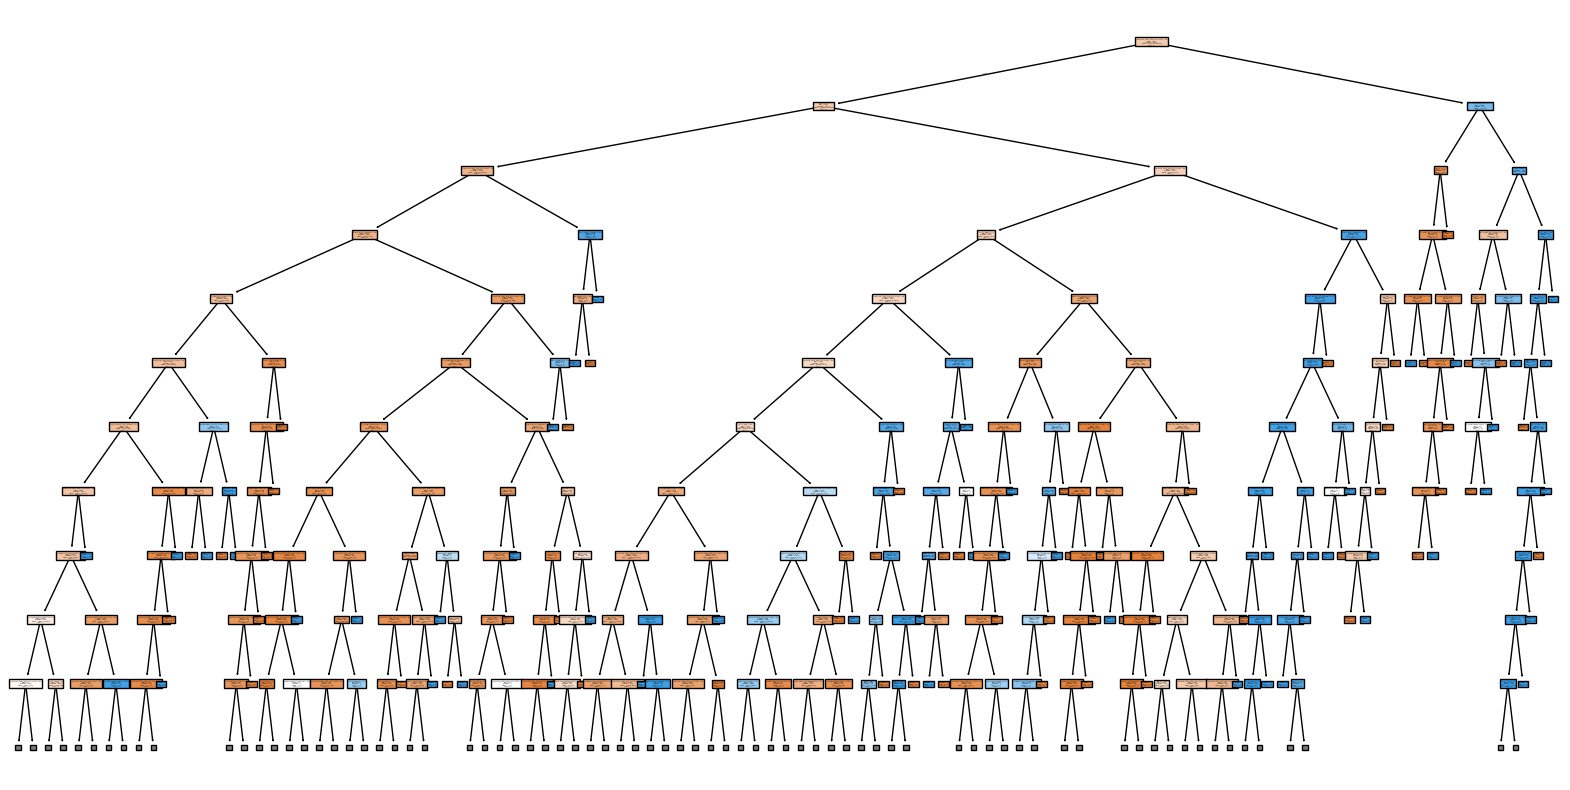

In [29]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(rf_classifier.estimators_[0],
          feature_names=X1.columns,
          class_names=['0', '1'],
          filled=True,
          max_depth=10)
plt.show()

In [30]:
import joblib

joblib.dump(rf_classifier, 'random_forest_model.joblib')


['random_forest_model.joblib']

In [33]:
import joblib


model_columns = list(X1.columns)
joblib.dump(model_columns, 'model_columns.joblib')



['model_columns.joblib']